C:\Users\91807\AppData\Local\Temp\ipykernel_25856\3962427478.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')
C:\Users\91807\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0449 - val_loss: 0.0282
Epoch 2/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0274 - val_loss: 0.0275
Epoch 3/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0266 - val_loss: 0.0286
Epoch 4/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0252 - val_loss: 0.0265
Epoch 5/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0254 - val_loss: 0.0259
Epoch 6/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0246 - val_loss: 0.0267
Epoch 7/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0237 - val_loss: 0.0255
Epoch 8/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0236 - val_loss: 0.0252
Epoch 9/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0232 - val_loss: 0.0244
Epoch 10/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0229 - val_loss: 0.0248
Epoch 11/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0227 - val_loss: 0.0253
Epoch 12/20
1095/1095 ━━━━━━━━

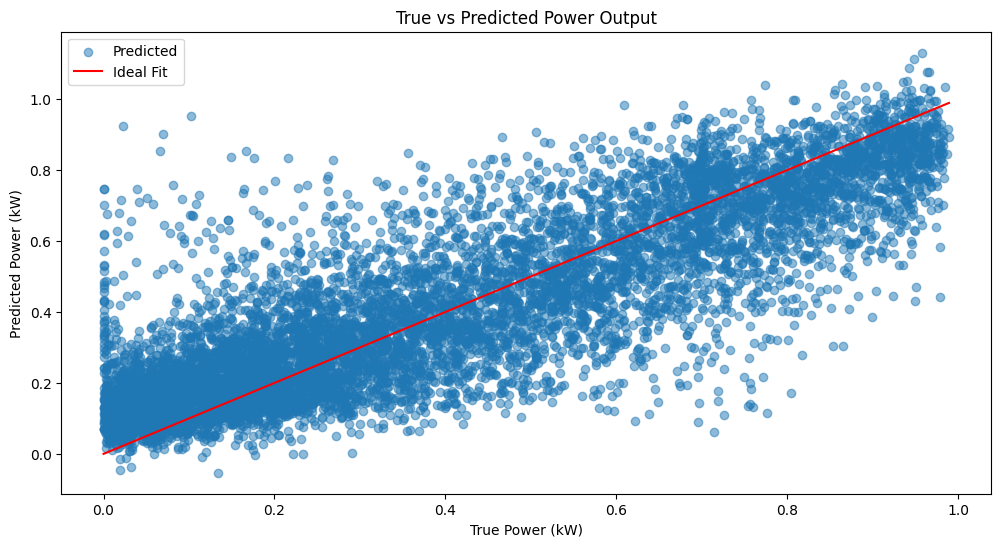

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

data = pd.read_csv('Location1.csv')
data['Time'] = pd.to_datetime(data['Time'])
data['hour'] = data['Time'].dt.hour
data['day_of_week'] = data['Time'].dt.dayofweek
data['month'] = data['Time'].dt.month
features = [
    'temperature_2m', 'relativehumidity_2m', 'dewpoint_2m', 
    'windspeed_10m', 'windspeed_100m', 'winddirection_10m', 
    'winddirection_100m', 'windgusts_10m', 'hour', 'day_of_week', 'month'
]
target = 'Power'
data = data.fillna(method='ffill')


X = data[features]
y = data[target]
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)


def gaussian(x, mean, sigma):
    return np.exp(- (x - mean)**2 / (2 * sigma**2))


num_mfs = 3
n_features = X_train.shape[1]
def fuzzify(X, num_mfs):
    fuzzified = []
    for i in range(X.shape[1]):
        feature_range = np.linspace(0, 1, num_mfs)
        fuzzified_feature = np.array([gaussian(X[:, i], mean, 0.1) for mean in feature_range]).T
        fuzzified.append(fuzzified_feature)
    return np.hstack(fuzzified)
X_fuzzified_train = fuzzify(X_train, num_mfs)
X_fuzzified_test = fuzzify(X_test, num_mfs)


model = Sequential([
    Dense(64, activation='relu', input_shape=(X_fuzzified_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='Adam', loss='mean_squared_error')
history = model.fit(X_fuzzified_train, y_train, epochs=20, batch_size=32, validation_data=(X_fuzzified_test, y_test), verbose=1)
y_pred_scaled = model.predict(X_fuzzified_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_original = scaler_y.inverse_transform(y_test)


mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
print(f"Neural Network Model MAE: {mae}")
print(f"Neural Network Model MSE: {mse}")


results = pd.DataFrame({
    'True Power (kW)': y_test_original.flatten(),
    'Predicted Power (kW)': y_pred.flatten()
})

plt.figure(figsize=(12, 6))
plt.scatter(results['True Power (kW)'], results['Predicted Power (kW)'], alpha=0.5, label='Predicted')
plt.plot([results['True Power (kW)'].min(), results['True Power (kW)'].max()],
         [results['True Power (kW)'].min(), results['True Power (kW)'].max()],
         color='red', label='Ideal Fit')
plt.title('True vs Predicted Power Output')
plt.xlabel('True Power (kW)')
plt.ylabel('Predicted Power (kW)')
plt.legend()
plt.show()


In [3]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
r2

0.718659781756432